## This notebook generates Figure S3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from glob import glob
from tqdm import tqdm
import xarray as xr
import os, sys
import scipy
import pandas as pd
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from scipy import stats

from scipy import interpolate

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
# from cinplaAnalysis.utils import *
import quantities as pq
%matplotlib inline

In [2]:
from icsd import StandardCSD, DeltaiCSD, StepiCSD

In [3]:
import matplotlib

font = {'size'   : 12}

matplotlib.rc('font', **font)

In [4]:
matplotlib.rcParams['savefig.pad_inches'] = 0

In [5]:
def plotFig(ax,csd,breaks=None,absmax=None,timeLimited=False,plotCB=True,xlabels=False,title=None):

    if breaks is not None:
        for b in breaks:
            ax.plot([0,3000],[b,b],c='k')

    if absmax is None:
        absmax = np.max(np.abs(csd))

    rms = np.mean(np.sqrt(csd**2))
    
    #im = ax.imshow(np.array(csd)/rms, origin='lower',cmap='bwr_r',vmin=-0.1,vmax=.1)#, vmin =-absmax,vmax=absmax, cmap='bwr_r')
    im = ax.imshow(np.array(csd), origin='lower', vmin =-absmax,vmax=absmax, cmap='bwr_r')
    ax.axis(ax.axis('tight'))

    if plotCB:
        cb = plt.colorbar(im, ax=ax)
        cb.formatter.set_powerlimits((0,0))

                # Get the scientific notation text (e.g. 1e3)
        offset = cb.ax.yaxis.get_offset_text()
        
        # Move it: x > 1 pushes right of colorbar, y > 1 pushes above
        offset.set_x(5)
        offset.set_y(1.02)


    ax.set_yticklabels([])

    if xlabels:
        ax.set_xticks([0,50],labels=['0','50'])
        # ax.set_xlabel('Time (ms)')
    else:
        ax.set_xticklabels([])

    if timeLimited:
        ax.set_xlim([50,100])
    else:
        ax.set_xlim([0,50])

    if title:
        plt.title(title)

    plt.tight_layout()

In [6]:
# Loads oCSD averaged over trials, with 20 um spacing, for various values of rho

lowRes = np.load('radii/total.npy')[:50]/10

In [7]:
idx_200 = np.arange(101) # Indices in the output file for objective disk CSD with 200 um rho
idx_100 = np.arange(101,202) # Indices in the output file for objective disk CSD with 100 um rho
idx_50 = np.arange(202,303) # Indices in the output file for objective disk CSD with 500 um rho
idx_20 = np.arange(303,404) # Indices in the output file for objective disk CSD with 20 um rho
idx_10 = np.arange(404,505) # Indices in the output file for objective disk CSD with 10 um rho

disk200 = lowRes[:,idx_200]
disk100 = lowRes[:,idx_100]
disk50 = lowRes[:,idx_50]
disk20 = lowRes[:,idx_20]
disk10 = lowRes[:,idx_10]

In [8]:
originalData = np.load('highRes/total.npy')[1950:2000]/10 # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um

disk_fullDensity_idx = np.arange(202,303)
disk500 = originalData[:,disk_fullDensity_idx] # oCSD, 20um spacing, rho = 500 um




In [9]:
### Calculates oCSD for 40 and 80 um electrode spacing, with rho of 500 um, by taking the sum of neighboring electrodes in the 20 um case

disk500_lowRes = np.zeros([originalData.shape[0],51])
disk500_verylowRes = np.zeros([originalData.shape[0],26])

for l in range(disk500_lowRes.shape[1]):
    if l == 0:
        disk500_lowRes[:,l] = disk500[:,2*l]+.5*disk500[:,2*l+1]
    elif l == disk500_lowRes.shape[1]-1:
        disk500_lowRes[:,l] = disk500[:,2*l]+.5*disk500[:,2*l-1]
    else:
        disk500_lowRes[:,l] = disk500[:,2*l]+.5*disk500[:,2*l-1]+.5*disk500[:,2*l+1]

for l in range(disk500_verylowRes.shape[1]):
    if l == 0:
        disk500_verylowRes[:,l] = disk500_lowRes[:,2*l]+.5*disk500_lowRes[:,2*l+1]
    elif l == disk500_verylowRes.shape[1]-1:
        disk500_verylowRes[:,l] = disk500_lowRes[:,2*l]+.5*disk500_lowRes[:,2*l-1]
    else:
        disk500_verylowRes[:,l] = disk500_lowRes[:,2*l]+.5*disk500_lowRes[:,2*l-1]+.5*disk500_lowRes[:,2*l+1]

In [10]:
### Calculates oCSD for 40 um electrode spacing, with various rho, by taking the sum of neighboring electrodes in the 20 um case

disk200_lowRes = np.zeros([50,51])
disk100_lowRes = np.zeros([50,51])
disk50_lowRes = np.zeros([50,51])
disk20_lowRes = np.zeros([50,51])
disk10_lowRes = np.zeros([50,51])

for l in range(disk200_lowRes.shape[1]):
    if l == 0:
        disk200_lowRes[:,l] = disk200[:,2*l]+.5*disk200[:,2*l+1]
    elif l == disk200_lowRes.shape[1]-1:
        disk200_lowRes[:,l] = disk200[:,2*l]+.5*disk200[:,2*l-1]
    else:
        disk200_lowRes[:,l] = disk200[:,2*l]+.5*disk200[:,2*l-1]+.5*disk200[:,2*l+1]

for l in range(disk100_lowRes.shape[1]):
    if l == 0:
        disk100_lowRes[:,l] = disk100[:,2*l]+.5*disk100[:,2*l+1]
    elif l == disk100_lowRes.shape[1]-1:
        disk100_lowRes[:,l] = disk100[:,2*l]+.5*disk100[:,2*l-1]
    else:
        disk100_lowRes[:,l] = disk100[:,2*l]+.5*disk100[:,2*l-1]+.5*disk100[:,2*l+1]

for l in range(disk50_lowRes.shape[1]):
    if l == 0:
        disk50_lowRes[:,l] = disk50[:,2*l]+.5*disk50[:,2*l+1]
    elif l == disk50_lowRes.shape[1]-1:
        disk50_lowRes[:,l] = disk50[:,2*l]+.5*disk50[:,2*l-1]
    else:
        disk50_lowRes[:,l] = disk50[:,2*l]+.5*disk50[:,2*l-1]+.5*disk50[:,2*l+1]

for l in range(disk20_lowRes.shape[1]):
    if l == 0:
        disk20_lowRes[:,l] = disk20[:,2*l]+.5*disk20[:,2*l+1]
    elif l == disk20_lowRes.shape[1]-1:
        disk20_lowRes[:,l] = disk20[:,2*l]+.5*disk20[:,2*l-1]
    else:
        disk20_lowRes[:,l] = disk20[:,2*l]+.5*disk20[:,2*l-1]+.5*disk20[:,2*l+1]

for l in range(disk10_lowRes.shape[1]):
    if l == 0:
        disk10_lowRes[:,l] = disk10[:,2*l]+.5*disk10[:,2*l+1]
    elif l == disk10_lowRes.shape[1]-1:
        disk10_lowRes[:,l] = disk10[:,2*l]+.5*disk10[:,2*l-1]
    else:
        disk10_lowRes[:,l] = disk10[:,2*l]+.5*disk10[:,2*l-1]+.5*disk10[:,2*l+1]


In [11]:
### Calculates oCSD for 80 um electrode spacing, with various rho, by taking the sum of neighboring electrodes in the 40 um case


disk200_verylowRes = np.zeros([50,26])
disk100_verylowRes = np.zeros([50,26])
disk50_verylowRes = np.zeros([50,26])
disk20_verylowRes = np.zeros([50,26])
disk10_verylowRes = np.zeros([50,26])


for l in range(disk200_verylowRes.shape[1]):
    if l == 0:
        disk200_verylowRes[:,l] = disk200_lowRes[:,2*l]+.5*disk200_lowRes[:,2*l+1]
    elif l == disk200_verylowRes.shape[1]-1:
        disk200_verylowRes[:,l] = disk200_lowRes[:,2*l]+.5*disk200_lowRes[:,2*l-1]
    else:
        disk200_verylowRes[:,l] = disk200_lowRes[:,2*l]+.5*disk200_lowRes[:,2*l-1]+.5*disk200_lowRes[:,2*l+1]

for l in range(disk100_verylowRes.shape[1]):
    if l == 0:
        disk100_verylowRes[:,l] = disk100_lowRes[:,2*l]+.5*disk100_lowRes[:,2*l+1]
    elif l == disk100_verylowRes.shape[1]-1:
        disk100_verylowRes[:,l] = disk100_lowRes[:,2*l]+.5*disk100_lowRes[:,2*l-1]
    else:
        disk100_verylowRes[:,l] = disk100_lowRes[:,2*l]+.5*disk100_lowRes[:,2*l-1]+.5*disk100_lowRes[:,2*l+1]

for l in range(disk50_verylowRes.shape[1]):
    if l == 0:
        disk50_verylowRes[:,l] = disk50_lowRes[:,2*l]+.5*disk50_lowRes[:,2*l+1]
    elif l == disk50_verylowRes.shape[1]-1:
        disk50_verylowRes[:,l] = disk50_lowRes[:,2*l]+.5*disk50_lowRes[:,2*l-1]
    else:
        disk50_verylowRes[:,l] = disk50_lowRes[:,2*l]+.5*disk50_lowRes[:,2*l-1]+.5*disk50_lowRes[:,2*l+1]

for l in range(disk20_verylowRes.shape[1]):
    if l == 0:
        disk20_verylowRes[:,l] = disk20_lowRes[:,2*l]+.5*disk20_lowRes[:,2*l+1]
    elif l == disk20_verylowRes.shape[1]-1:
        disk20_verylowRes[:,l] = disk20_lowRes[:,2*l]+.5*disk20_lowRes[:,2*l-1]
    else:
        disk20_verylowRes[:,l] = disk20_lowRes[:,2*l]+.5*disk20_lowRes[:,2*l-1]+.5*disk20_lowRes[:,2*l+1]

for l in range(disk10_verylowRes.shape[1]):
    if l == 0:
        disk10_verylowRes[:,l] = disk10_lowRes[:,2*l]+.5*disk10_lowRes[:,2*l+1]
    elif l == disk10_verylowRes.shape[1]-1:
        disk10_verylowRes[:,l] = disk10_lowRes[:,2*l]+.5*disk10_lowRes[:,2*l-1]
    else:
        disk10_verylowRes[:,l] = disk10_lowRes[:,2*l]+.5*disk10_lowRes[:,2*l-1]+.5*disk10_lowRes[:,2*l+1]



In [19]:
### Calculates oCSD for 160 um electrode spacing, with various rho, by taking the sum of neighboring electrodes in the 80 um case


disk200_veryverylowRes = np.zeros([50,13])
disk100_veryverylowRes = np.zeros([50,13])
disk50_veryverylowRes = np.zeros([50,13])
disk20_veryverylowRes = np.zeros([50,13])
disk10_veryverylowRes = np.zeros([50,13])


for l in range(disk200_veryverylowRes.shape[1]):
    if l == 0:
        disk200_veryverylowRes[:,l] = disk200_verylowRes[:,2*l]+.5*disk200_verylowRes[:,2*l+1]
    elif l == disk200_verylowRes.shape[1]-1:
        disk200_veryverylowRes[:,l] = disk200_verylowRes[:,2*l]+.5*disk200_verylowRes[:,2*l-1]
    else:
        disk200_veryverylowRes[:,l] = disk200_verylowRes[:,2*l]+.5*disk200_verylowRes[:,2*l-1]+.5*disk200_verylowRes[:,2*l+1]

for l in range(disk100_veryverylowRes.shape[1]):
    if l == 0:
        disk100_veryverylowRes[:,l] = disk100_verylowRes[:,2*l]+.5*disk100_verylowRes[:,2*l+1]
    elif l == disk100_verylowRes.shape[1]-1:
        disk100_veryverylowRes[:,l] = disk100_verylowRes[:,2*l]+.5*disk100_verylowRes[:,2*l-1]
    else:
        disk100_veryverylowRes[:,l] = disk100_verylowRes[:,2*l]+.5*disk100_verylowRes[:,2*l-1]+.5*disk100_verylowRes[:,2*l+1]

for l in range(disk50_veryverylowRes.shape[1]):
    if l == 0:
        disk50_veryverylowRes[:,l] = disk50_verylowRes[:,2*l]+.5*disk50_verylowRes[:,2*l+1]
    elif l == disk50_verylowRes.shape[1]-1:
        disk50_veryverylowRes[:,l] = disk50_verylowRes[:,2*l]+.5*disk50_verylowRes[:,2*l-1]
    else:
        disk50_veryverylowRes[:,l] = disk50_verylowRes[:,2*l]+.5*disk50_verylowRes[:,2*l-1]+.5*disk50_verylowRes[:,2*l+1]

for l in range(disk20_veryverylowRes.shape[1]):
    if l == 0:
        disk20_veryverylowRes[:,l] = disk20_verylowRes[:,2*l]+.5*disk20_verylowRes[:,2*l+1]
    elif l == disk20_verylowRes.shape[1]-1:
        disk20_veryverylowRes[:,l] = disk20_verylowRes[:,2*l]+.5*disk20_verylowRes[:,2*l-1]
    else:
        disk20_veryverylowRes[:,l] = disk20_verylowRes[:,2*l]+.5*disk20_verylowRes[:,2*l-1]+.5*disk20_verylowRes[:,2*l+1]


In [12]:
depthHighRes = np.linspace(0,2000,51)


In [22]:
### This cell calculates the iCSD from the recorded LFP

highRes = np.load('highRes/total.npy')[1950:2000]/10
lfpIdx = np.arange(101) # Indices in the output file for LFP electrodes
totalLFPHighRes = highRes[:,lfpIdx] # 20 um electrode spacing
totalLFPLowRes = highRes[:,0:totalLFPHighRes.shape[1]:2] # 40 um electrode spacing
totalLFPVeryLowRes = totalLFPLowRes[:,0:totalLFPLowRes.shape[1]:2] # 80 um electrode spacing
totalLFPVeryVeryLowRes = totalLFPVeryLowRes[:,0:totalLFPVeryLowRes.shape[1]:2] # 80 um electrode spacing

diams = [1000,400,200,100,40,20] # Various values of rho (note iCSD takes diameter, while oCSD takes radius as the parameter)

icsds = [] # 20 um electrode spacing
icsds_low = [] # 40 um electrode spacing
icsds_veryLow = []# 80 um electrode spacing
icsds_veryVeryLow = []# 1600 um electrode spacing

for diam in diams:

    diam *= 1e-6* pq.m                              # [m]
    sigma = 0.277 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.277 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':20E-6 * pq.m ,
        'f_type' : 'identity',
        'f_order' : (3, 1),
        'diam':diam,
    'sigma_top':sigma_top,
    'tol':1e-12
    }

    step_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':40E-6 * pq.m ,
        'f_type' : 'identity',
        'f_order' : (3, 1),
        'diam':diam,
    'sigma_top':sigma_top,
    'tol':1e-12
    }

    step_input_verylow = {
        'lfp' : totalLFPVeryLowRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,26) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':80E-6 * pq.m ,
        'f_type' : 'identity',
        'f_order' : (3, 1),
        'diam':diam,
    'sigma_top':sigma_top,
    'tol':1e-12
    }

    step_input_veryVerylow = {
        'lfp' : totalLFPVeryVeryLowRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,13) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':160E-6 * pq.m ,
        'f_type' : 'identity',
        'f_order' : (3, 1),
        'diam':diam,
    'sigma_top':sigma_top,
    'tol':1e-12
    }
    
    icsd_high = StepiCSD(**step_input_high)
    icsd_low = StepiCSD(**step_input_low)
    icsd_verylow = StepiCSD(**step_input_verylow)
    icsd_veryverylow = StepiCSD(**step_input_veryVerylow)
    
    icsds.append(icsd_high)
    icsds_low.append(icsd_low)
    icsds_veryLow.append(icsd_verylow)
    icsds_veryVeryLow.append(icsd_veryverylow)

In [14]:
#### Here, we calculate standard CSD, in addition to iCSD, for 20, 40, and 80 um electrode spacings

std_input_high = {
    'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
    'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
    'sigma' : sigma,
    'f_type' : 'gaussian',
    'f_order' : (3, 1)
}

std_input_low = {
    'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
    'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
    'sigma' : sigma,
    'f_type' : 'gaussian',
    'f_order' : (3, 1)
}

std_input_low_half = {
    'lfp' : totalLFPVeryLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
    'coord_electrode' : 80 * np.arange(0,totalLFPVeryLowRes.shape[1]) * 1e-6 * pq.m,
    'sigma' : sigma,
    'f_type' : 'gaussian',
    'f_order' : (3, 1)
}

icsd_high_std = StandardCSD(**std_input_high)
icsd_low_std = StandardCSD(**std_input_low)
icsd_low_half_std = StandardCSD(**std_input_low_half)

In [15]:
def twoD_correlation(a, b):
    """
    Compute the normalized 2D cross-correlation between two arrays.
    Result values range from -1 (anticorrelated) to 1 (perfectly correlated).
    """
    a = a.astype(float)
    b = b.astype(float)
    # a[np.where(a>10)]=10
    # a[np.where(a<-10)]=-10

    # b[np.where(b>10)]=10
    # b[np.where(b<-10)]=-10
    
    a_mean = a.mean()
    b_mean = b.mean()
    num = np.sum((a - a_mean) * (b - b_mean))
    den = np.sqrt(np.sum((a - a_mean)**2) * np.sum((b - b_mean)**2))

    return num/den

In [16]:
noNeg = np.load('secondDeriv/total.npy')[:50]/10 # Loads nnCSD, with 20 um electrode spacing

In [20]:
def makeCorrelationMatrices(icsdList,ocsdList):

    correlationMatrices = np.zeros((len(icsdList),len(ocsdList)))
    for i in range(len(icsdList)):
        icsd = icsdList[i]
        for j in range(len(ocsdList)):
            ocsd = ocsdList[j]

            if icsd.shape!=ocsd.shape:
                ocsd=ocsd[1:-1]
                
            corr = twoD_correlation(icsd,ocsd)
            correlationMatrices[i,j] = corr

    return correlationMatrices

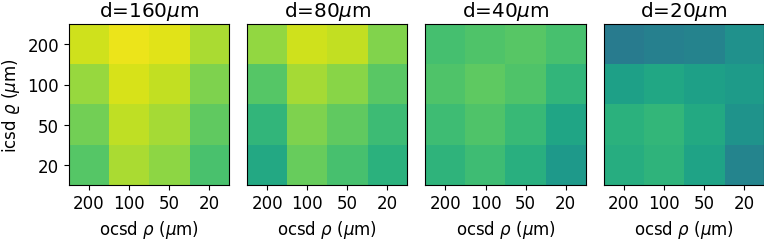

In [25]:
icsdList_high = [icsd.get_csd() for icsd in icsds[1:-1]]
icsdList_low = [icsd.get_csd() for icsd in icsds_low[1:-1]]
icsdList_half = [icsd.get_csd() for icsd in icsds_veryLow[1:-1]]
icsdList_quarter = [icsd.get_csd() for icsd in icsds_veryVeryLow[1:-1]]

ocsdList_high = [disk200.T,disk100.T,disk50.T,disk20.T]
ocsdList_low = [disk200_lowRes.T,disk100_lowRes.T,disk50_lowRes.T,disk20_lowRes.T]
ocsdList_half = [disk200_verylowRes.T,disk100_verylowRes.T,disk50_verylowRes.T,disk20_verylowRes.T]
ocsdList_quarter = [disk200_veryverylowRes.T,disk100_veryverylowRes.T,disk50_veryverylowRes.T,disk20_veryverylowRes.T]

corrHigh = makeCorrelationMatrices(icsdList_high,ocsdList_high)
corrLow = makeCorrelationMatrices(icsdList_low,ocsdList_low)
corrHalf = makeCorrelationMatrices(icsdList_half,ocsdList_half)
corrQuarter = makeCorrelationMatrices(icsdList_quarter,ocsdList_quarter)

fig, ax = plt.subplots(1,4,figsize=(8,3))

ax[3].imshow(corrHigh,vmin=0,vmax=1)
ax[3].set_xticks([0,1,2,3],['200','100','50','20'])
ax[3].set_yticks([])
ax[3].set_xlabel(r'ocsd $\rho$ ($\mu$m)')
ax[3].set_title(r'd=20$\mu$m')

ax[2].imshow(corrLow,vmin=0,vmax=1)
ax[2].set_xticks([0,1,2,3],['200','100','50','20'])
ax[2].set_yticks([])
ax[2].set_xlabel(r'ocsd $\rho$ ($\mu$m)')
ax[2].set_title(r'd=40$\mu$m')

ax[1].imshow(corrHalf,vmin=0,vmax=1)
ax[1].set_xticks([0,1,2,3],['200','100','50','20'])
ax[1].set_yticks([])
ax[1].set_xlabel(r'ocsd $\rho$ ($\mu$m)')
ax[1].set_title(r'd=80$\mu$m')

ax[0].imshow(corrQuarter,vmin=0,vmax=1)
ax[0].set_xticks([0,1,2,3],['200','100','50','20'])
ax[0].set_yticks([0,1,2,3],['200','100','50','20'])
ax[0].set_xlabel(r'ocsd $\rho$ ($\mu$m)')
ax[0].set_ylabel(r'icsd $\varrho$ ($\mu$m)')
ax[0].set_title(r'd=160$\mu$m')

plt.tight_layout()

plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/fullCorrMat_resting.png',dpi=600)


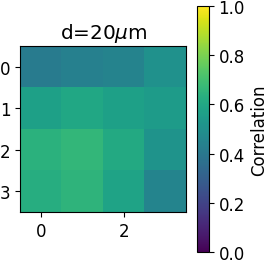

In [24]:

fig, ax = plt.subplots(1,1,figsize=(3,3))

im = ax.imshow(corrHigh,vmin=0,vmax=1)
ax.set_title(r'd=20$\mu$m')
fig.colorbar(im,ax=ax,label='Correlation')
plt.tight_layout()
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/fullCorrMat_resting_colorbar.png',dpi=600)


[[0.41480795 0.4371088  0.44792542 0.50566637]
 [0.56894524 0.59420752 0.56998268 0.55063264]
 [0.63767672 0.66320471 0.60814101 0.51244554]
 [0.62384614 0.65034326 0.58146623 0.45150642]]


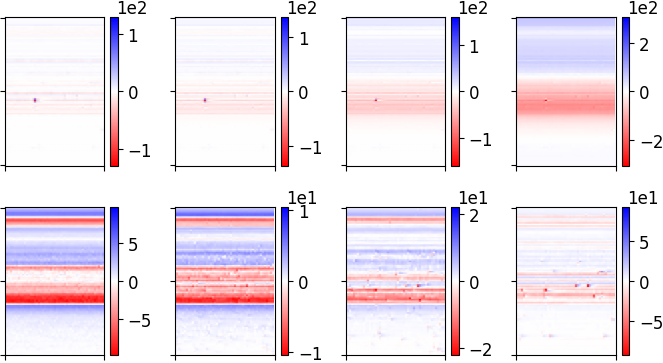

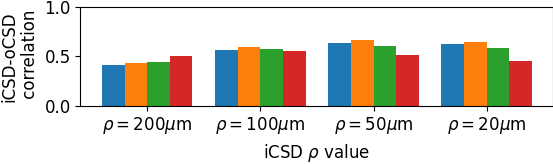

In [19]:
fig, axes = plt.subplots(2,4,figsize=(7,4))
# plotFig(axes[0][0],icsds[0].get_csd())
plotFig(axes[0][0],icsds[1].get_csd())
plotFig(axes[0][1],icsds[2].get_csd())
plotFig(axes[0][2],icsds[3].get_csd())
plotFig(axes[0][3],icsds[4].get_csd())
# plotFig(axes[1][0],sCsd_high_new.get_csd())
# plotFig(axes[1][1],sCsd_high_new.get_csd())
# plotFig(axes[1][2],sCsd_high_new.get_csd())
# plotFig(axes[1][3],sCsd_high_new.get_csd())
# plotFig(axes[2][0],nncsd.T)
# plotFig(axes[2][1],nncsd.T)
# plotFig(axes[2][2],nncsd.T)
# plotFig(axes[2][3],nncsd.T)
# plotFig(axes[1][0],disk500.T*1e-12/(np.pi*500e-6**2*20e-6))
plotFig(axes[1][0],disk200.T*1e-12/(np.pi*200e-6**2*20e-6))
plotFig(axes[1][1],disk100.T*1e-12/(np.pi*100e-6**2*20e-6))
plotFig(axes[1][2],disk50.T*1e-12/(np.pi*50e-6**2*20e-6))
plotFig(axes[1][3],disk20.T*1e-12/(np.pi*20e-6**2*20e-6))


plt.tight_layout()
plt.savefig('radii_resting_dense.png',dpi=600)



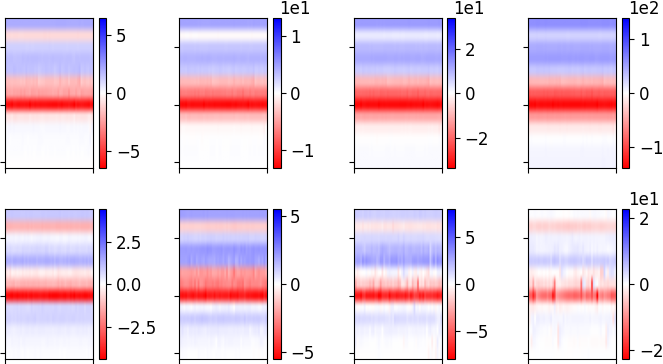

In [28]:
fig, axes = plt.subplots(2,4,figsize=(7,4))
# plotFig(axes[0][0],icsds[0].get_csd())
plotFig(axes[0][0],icsds_veryVeryLow[1].get_csd())
plotFig(axes[0][1],icsds_veryVeryLow[2].get_csd())
plotFig(axes[0][2],icsds_veryVeryLow[3].get_csd())
plotFig(axes[0][3],icsds_veryVeryLow[4].get_csd())

plotFig(axes[1][0],disk200_veryverylowRes.T*1e-12/(np.pi*200e-6**2*160e-6))
plotFig(axes[1][1],disk100_veryverylowRes.T*1e-12/(np.pi*100e-6**2*160e-6))
plotFig(axes[1][2],disk50_veryverylowRes.T*1e-12/(np.pi*50e-6**2*160e-6))
plotFig(axes[1][3],disk20_veryverylowRes.T*1e-12/(np.pi*20e-6**2*160e-6))


plt.tight_layout()
plt.savefig('radii_resting_coarse.png',dpi=600)

In [49]:
icsds[0].get_csd().shape

(101, 50)